# Homework 2 - PCA

In this homework, we will be using techniques such as PCA (Principal Component Analysis) to explore, analyze, and visualize the UCI Wisconsin Breast Cancer (Diagnostic) Dataset.

In [188]:
''' Dependencies required for this assignment '''
from pprint import pprint  # Pretty printing
import pandas as pd  # Dataframe management
import numpy as np  # Numrical computations
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical Computing
import matplotlib.pyplot as plt  # Data Visualization with Static Plots
import plotly.graph_objects as go  # Interative Data Visualization
from sklearn.decomposition import PCA  # Dimensionality Reduction
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Data standardization and normalization
from sklearn.model_selection import train_test_split  # Data Splitting
from sklearn.neighbors import KNeighborsClassifier  # ML Models
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report  # Evaluating Model Performance
import seaborn as sns  # Heatmap visualization

## Problem 1 - Loading the Dataset
Loading the breast cancer dataset from the provided *csv* file.

In [189]:
df_bc = pd.read_csv('./data/breast-cancer-wisconsin.data')
df_bc

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1
0,1002945,5,4,4,5,7,10,3,2,1,2
1,1015425,3,1,1,1,2,2,3,1,1,2
2,1016277,6,8,8,1,3,4,3,7,1,2
3,1017023,4,1,1,3,2,1,3,1,1,2
4,1017122,8,10,10,8,7,10,9,7,1,4
...,...,...,...,...,...,...,...,...,...,...,...
693,776715,3,1,1,1,3,2,1,1,1,2
694,841769,2,1,1,1,2,1,1,1,1,2
695,888820,5,10,10,3,7,3,8,10,2,4
696,897471,4,8,6,4,3,4,10,6,1,4


## Problem 2 - Cleaning the Dataset

Creating a new dataframe containing only records with complete data, verifying that the new (cleaned) dataframe contains only records with complete data records.

When initially cleaning the dataset, we should note that (as stated in the .names file of the data) some incomplete samples are filled with a "?". This will not be covered by panda's `dropna()` function, so we should firstly replace then values with NaN values.

In [190]:
df_bc = df_bc.replace('?', np.nan)  # Replace all '?' values with numpy's NaN (to drop)

Now, we can take the approach of dropping incomplete samples and perform dropna() as normal.

In [191]:
clean_df = df_bc.dropna(how="any")  # Drop any NA values
print(f"Incomplete Records:\n{clean_df.isna().sum()}")  # Verify all records are complete
clean_df = clean_df.drop_duplicates()  # Drop any duplicate values
clean_df.info()  # Printing essential info for df evalulation

Incomplete Records:
1000025    0
5          0
1          0
1.1        0
1.2        0
2          0
1.3        0
3          0
1.4        0
1.5        0
2.1        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 674 entries, 0 to 697
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   1000025  674 non-null    int64 
 1   5        674 non-null    int64 
 2   1        674 non-null    int64 
 3   1.1      674 non-null    int64 
 4   1.2      674 non-null    int64 
 5   2        674 non-null    int64 
 6   1.3      674 non-null    object
 7   3        674 non-null    int64 
 8   1.4      674 non-null    int64 
 9   1.5      674 non-null    int64 
 10  2.1      674 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 63.2+ KB


## Problem 3 - Pre-processing

Creating a new column "target" containing integer re-categorizations of the original Class field.

When first attempting this problem, it seemed intuitive to map each unique target to a number, such as:

```py
unique_raw_target_vals = clean_df.iloc[:,-1].unique()
for i in range(len(unique_raw_target_vals)):
   clean_df.loc[clean_df.iloc[:,-1] == unique_raw_target_vals[i], 'target'] = i

```

However, this would not work as the target is already in numerical values. Therefore, one approach could be to **normalize** the data, essentially mapping each value to 0 or 1. 

In [192]:
normalize_scaler = MinMaxScaler()  # Create a min-max scaler (normalization)
# Create a new column of the normalized target values as ints
clean_df['target'] = normalize_scaler.fit_transform(clean_df.iloc[:,[-1]]).astype("int32")
clean_df['target'].unique()

array([0, 1])

Alternatively, we achieve the same result by using panda's `factorize` functionality [[1]](https://pandas.pydata.org/docs/reference/api/pandas.factorize.html#pandas.factorize), which maps categorical data into integer representations (such as 0, 1, 2, 3, ...). In this case, it will simply map 2 -> 0 and 4 -> 1.

In [193]:
clean_df_copy = clean_df.copy()
clean_df_copy['target'] = pd.factorize(clean_df_copy.iloc[:, -1])[0].astype("int32")
clean_df_copy['target'].unique()

array([0, 1])

Additionally, we must consider the feature data. In order to account for different scales and preserve outliers, we can **standardize** the data (excluding the first column of IDs, which is purely an identifier and will *not* be considered as a feature).

In [194]:
# Casting feature columns to floats to avoid future depracation warnings
cols = clean_df.columns[1:-2]  # Extract the specific columns to easier for-loop
clean_df = clean_df.astype({c: 'float64' for c in cols})  # Convert each feature datatype to a float

# Saving an un-standardized copy for later steps
unstandardized_clean_df = clean_df.copy()

# Applying standardization to the features
standardize_scaler = StandardScaler()  # Making a standardization scaler
scaled_features: np.array = standardize_scaler.fit_transform(clean_df[cols])  # Applying the standardization transformation
clean_df[cols] = pd.DataFrame(scaled_features, index=clean_df.index, columns=cols)  # Mapping to numpy array back to the dataframe
clean_df.reset_index(drop=True, inplace=True)  # Resetting the index after dropping rows
clean_df

,1000025,5,1,1.1,1.2,2,1.3,3,1.4,1.5,2.1,target
0,1002945,0.194613,0.278383,0.264788,0.747250,1.706778,1.775982,-0.180787,-0.289983,-0.349432,2,0
1,1015425,-0.514410,-0.703973,-0.743502,-0.644038,-0.557727,-0.423902,-0.180787,-0.616274,-0.349432,2,0
2,1016277,0.549125,1.588190,1.609175,-0.644038,-0.104826,0.126069,-0.180787,1.341474,-0.349432,2,0
3,1017023,-0.159899,-0.703973,-0.743502,0.051606,-0.557727,-0.698887,-0.180787,-0.616274,-0.349432,2,0
4,1017122,1.258149,2.243094,2.281369,1.790715,1.706778,1.775982,2.264366,1.341474,-0.349432,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
669,776715,-0.514410,-0.703973,-0.743502,-0.644038,-0.104826,-0.423902,-0.995838,-0.616274,-0.349432,2,0
670,841769,-0.868922,-0.703973,-0.743502,-0.644038,-0.557727,-0.698887,-0.995838,-0.616274,-0.349432,2,0
671,888820,0.194613,2.243094,2.281369,0.051606,1.706778,-0.148916,1.856841,2.320348,0.225000,4,1
672,897471,-0.159899,1.588190,0.936982,0.399428,-0.104826,0.126069,2.671892,1.015183,-0.349432,4,1


## Problem 4 - Feature/Target Data Split

Next, we can create X and Y splits similarly to how we did before, excluding the ID field.

In [195]:
feature_cols = clean_df.columns[1:-2]  # Explicitly state the feature columns
target_col = clean_df.columns[-1]  # Explicitly state the target column
# Splitting the datasets
X = clean_df[feature_cols]
y = clean_df[target_col]
# Verifications
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"X column names: {X.columns}")

X shape: (674, 9), y shape: (674,)
X column names: Index(['5', '1', '1.1', '1.2', '2', '1.3', '3', '1.4', '1.5'], dtype='object')


## Problem 5 - Standardization of Feature Data

Although this was already achieved in the pre-processing step, we can break the logic out into a function and verify the results. This way, we ensure that *only the training data* gets standardized.

In [196]:
# Defining a function to standardize all given columns from a dataframe
def standardize_df(
                    df: pd.DataFrame, 
                    cols: pd.Index = None, 
                    inPlace: bool = False
                  ) -> pd.DataFrame | None :
    ''' 
    Standardizes a given dataframe at their given column indexes
        - df: input dataframe
        - cols: the column names to scale. If none, assumes all columns
        - inPlace: If true, modify the df and return None; else, return a new dataframe
    '''
    # Work on a copy unless inPlace is true
    out_df = df if inPlace else df.copy()
    
    # Set cols to equal all columns if no argument is received
    if cols is None:
        cols = df.columns
    
    # Convert each feature datatype to a float
    out_df.loc[:, cols] = (out_df.loc[:, cols].astype("float64"))  # Workaround to avoid copying
    
    # Fit/transform with the standard scaler 
    standardize_scaler = StandardScaler()  # Define the standardization scaler
    scaled_features = standardize_scaler.fit_transform(out_df[cols])  # Fit to the features
    
    # Assign the scaled features back to a dataframe
    out_df.loc[:, cols] = scaled_features
    
    return None if inPlace else out_df

# Example usage of function using copy of unstandaridized data from earlier
X = unstandardized_clean_df.loc[:, feature_cols].copy()  # Deep copy
standardize_df(X, cols=feature_cols, inPlace=True)

# Verifications - should be the same, where mean=0 and std=1
print("Description (if standardized, mean ~= 0 and standard deviation ~= 1")
X.describe()

Description (if standardized, mean ~= 0 and standard deviation ~= 1


,5,1,1.1,1.2,2,1.3,3,1.4,1.5
count,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02
mean,1.370483e-16,-2.108435e-17,-7.379524e-17,4.216871e-17,-1.475905e-16,1.054218e-16,2.108435e-17,-1.054218e-16,-6.325306e-17
std,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00
min,-1.223434e+00,-7.039729e-01,-7.435018e-01,-6.440383e-01,-1.010628e+00,-6.988875e-01,-9.958375e-01,-6.162744e-01,-3.494322e-01
25%,-8.689222e-01,-7.039729e-01,-7.435018e-01,-6.440383e-01,-5.577267e-01,-6.988875e-01,-5.883120e-01,-6.162744e-01,-3.494322e-01
50%,-1.598985e-01,-7.039729e-01,-7.435018e-01,-6.440383e-01,-5.577267e-01,-6.988875e-01,-1.807865e-01,-6.162744e-01,-3.494322e-01
75%,5.491252e-01,6.058345e-01,6.008851e-01,3.994276e-01,3.480752e-01,6.760400e-01,6.342645e-01,3.625998e-01,-3.494322e-01
max,1.967172e+00,2.243094e+00,2.281369e+00,2.486359e+00,3.065481e+00,1.775982e+00,2.671892e+00,2.320348e+00,4.820460e+00


## Problem 6 - Training a $k$-NN Model

First, we will need to split the data into training and testing sets.

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Validation
print(f"X_train: {X_train}, y_train: {y_train}")

X_train:             5         1       1.1       1.2         2       1.3         3  \
628 -0.159899 -0.703973 -0.743502 -0.644038 -0.557727 -0.698887 -0.995838   
180 -1.223434 -0.703973 -0.743502 -0.644038 -0.557727 -0.698887 -0.995838   
261  1.258149  1.588190  1.945272  0.399428  0.800976  1.775982  1.449315   
262  1.967172  0.278383  0.264788  2.486359  1.253877  1.775982  0.634264   
7   -0.868922 -0.703973 -0.743502 -0.644038 -0.557727 -0.698887 -0.995838   
..        ...       ...       ...       ...       ...       ...       ...   
73   1.967172  0.933286  0.264788 -0.644038 -0.104826  0.126069 -0.180787   
108  0.549125  0.605834  0.264788  0.399428 -0.104826  1.500997  1.449315   
284  1.258149  2.243094  2.281369  2.486359  2.159679  1.775982  2.671892   
456  1.258149  1.588190  1.945272  1.095072  1.253877 -0.148916  2.671892   
104  0.903637 -0.049069  0.264788  0.399428 -0.104826 -0.148916 -0.180787   

          1.4       1.5  
628 -0.616274 -0.349432  
180 -0.616274 

Then, we can define a function to test the $k$-NN model from $k ∈ {1, ..., 100}$.

In [198]:
def get_kNN_accuracy(
                      X_train: pd.DataFrame, 
                      X_test: pd.DataFrame, 
                      y_train: pd.DataFrame, 
                      y_test: pd.DataFrame,
                      k_val: int 
                    ) -> float:
    ''' Returns the accuracy of a given k for a k-NN model, given the train/test splits '''
    y_pred = KNeighborsClassifier(n_neighbors=k_val).fit(X_train, y_train).predict(X_test)  # Train the model with k nearest neighbors and get the test prediction
    return accuracy_score(y_test, y_pred)  # Return the accuracy score of that prediction

Now, we can use this function to test $k$, storing the results to visualize.

In [199]:
k_results = dict()  # Dictionary data structure (hashmap) to store results
k_optimal = 1  # Optimal k value
k_best_acc = 0  # Optimal k accuracy

# Retreive and store predictions for k ∈ {1, ..., 100}
for k in range(1, 101):
    cur_acc = get_kNN_accuracy(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, k_val=k)
    k_results[k] = cur_acc
    if k_best_acc < cur_acc:
        k_best_acc = cur_acc
        k_optimal = k
        
print(f"Best k: {k_optimal} with an accuracy of {k_best_acc}")

Best k: 19 with an accuracy of 0.9822485207100592


Now, we can visualize the accuracy results of all tested $k$ 's with a matplotlib line graph.

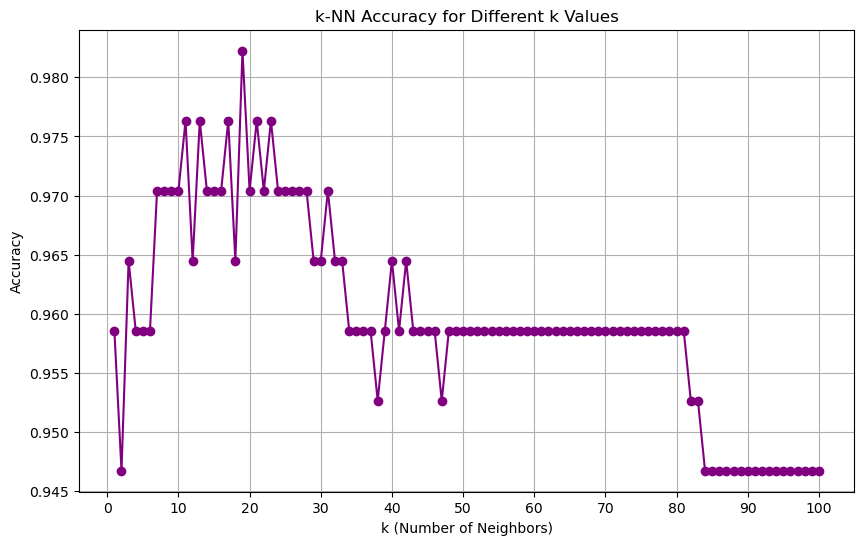

In [200]:
plt.figure(figsize=(10, 6))  # Setting the size (standard)
plt.style.use('seaborn-v0_8-dark-palette')  # Use a seaborn style for cool aesthetic
plt.plot(list(k_results.keys()), list(k_results.values()), marker='o', color="purple")  # Using k index as x-axis and accuracy as y-axis
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy for Different k Values')
plt.xticks(range(0, 101, 10))  # Setting x-tick interval to 10
plt.grid(True)
plt.show()
# print(plt.style.available)

## Problem 7 - Generating a Correlation Matrix

Generating and printing the correlation matrix.

In [201]:
R = X_train.corr()  # Generating the correlation matrix

# Printing the correlation matrix via console
print("Correlation Matrix:")
print(R.round(2))

# Visualizing the correlation matrix with a plotly heatmap
fig = go.Figure(data=go.Heatmap(
    z=R.values,  # Matrix values
    x=R.columns,  # x-axis labels
    y=R.index,  # y-axis labels
    colorscale='RdBu',
    zmin=-1,  # fixed minimum for correlation (-1)
    zmax=1,  # fixed maximum for correlation (1)
    colorbar=dict(title='Correlation Coefficient'),  # Adding the colorbar
))
fig.update_layout(
    title='Feature Correlation Matrix',  # Assigning a title
    xaxis_nticks=36,  # Number of ticks on x-axis
    yaxis_nticks=36,  # Number of ticks on y-axis
    width=800,
    height=800
)

fig.show()

Correlation Matrix:
        5     1   1.1   1.2     2   1.3     3   1.4   1.5
5    1.00  0.65  0.65  0.53  0.52  0.60  0.56  0.54  0.36
1    0.65  1.00  0.91  0.74  0.73  0.71  0.76  0.72  0.46
1.1  0.65  0.91  1.00  0.72  0.71  0.71  0.73  0.71  0.44
1.2  0.53  0.74  0.72  1.00  0.63  0.69  0.69  0.60  0.44
2    0.52  0.73  0.71  0.63  1.00  0.59  0.62  0.63  0.47
1.3  0.60  0.71  0.71  0.69  0.59  1.00  0.68  0.58  0.33
3    0.56  0.76  0.73  0.69  0.62  0.68  1.00  0.65  0.34
1.4  0.54  0.72  0.71  0.60  0.63  0.58  0.65  1.00  0.42
1.5  0.36  0.46  0.44  0.44  0.47  0.33  0.34  0.42  1.00


## Problem 8 - Principle Component Analysis (PCA)

Firstly, we can compute the eigenvalues and eigenvectors using numpy's linalg functionality.

In [202]:
eigenvalues, eigenvectors = np.linalg.eig(R)

Then, we can sort the eigenvalues/eigenvector pairs in descending order.

In [203]:
# Sorting the indices based on descending order of eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]

# Reordering the eigenvalues and eigenvectors
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Validation
print("Eigenvalues (sorted):")
print(eigenvalues.round(2))
print("\nEigenvectors (sorted):")
print(eigenvectors.round(2))

Eigenvalues (sorted):
[5.93 0.78 0.52 0.45 0.37 0.31 0.28 0.27 0.09]

Eigenvectors (sorted):
[[-0.3  -0.11  0.88  0.14  0.06  0.04 -0.01 -0.31 -0.  ]
 [-0.38 -0.05 -0.06  0.11  0.1   0.32  0.23  0.34  0.75]
 [-0.37 -0.08 -0.02  0.11  0.1   0.26  0.35  0.46 -0.65]
 [-0.34 -0.02 -0.23 -0.53 -0.02  0.04  0.48 -0.57 -0.02]
 [-0.33  0.15 -0.26  0.26  0.75 -0.22 -0.27 -0.21 -0.05]
 [-0.34 -0.27  0.09 -0.47 -0.05 -0.62 -0.21  0.38  0.05]
 [-0.34 -0.23 -0.19 -0.08 -0.29  0.48 -0.67 -0.14 -0.09]
 [-0.33  0.02 -0.21  0.59 -0.54 -0.4   0.13 -0.16  0.01]
 [-0.23  0.91  0.13 -0.2  -0.18  0.03 -0.14  0.13 -0.02]]


Next, we can compute the cumulative energy.

In [204]:
energy = eigenvalues / np.sum(eigenvalues)  # Get the energy of each eigenvalue
cumulative_energy = np.cumsum(energy)  # Getting the cumulative energy

# Validation
print("Cumulative Energy:")
print(cumulative_energy.round(2))

Cumulative Energy:
[0.66 0.75 0.8  0.85 0.89 0.93 0.96 0.99 1.  ]


Lastly, we can visualize the principle components using plotly.

In [205]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(range(1, len(cumulative_energy) + 1)),
    y=cumulative_energy * 100,  # Convert to percentage
    mode='lines+markers',
    line=dict(color='green')  # Connecting points with a green line
))
fig.update_layout(
    title='Cumulative Energy by Principal Components',
    xaxis_title='Principal Component',
    yaxis_title='Cumulative Energy (%)',
    yaxis=dict(range=[0, 101]),  # Set y-axis range from 0 to 101% (to see the full marker at 100%)
    width=800,
    height=500
)

## Problem 9 - Dimension Reduction I

First, we can determine the minimum number of principle components to capture 95% variance.

In [206]:
DESIRED_VARIANCE = 0.95

# Getting smallest k where cumulative energy >= 95%
k = int(np.argmax(cumulative_energy >= DESIRED_VARIANCE) + 1)

# Validation
print(f"Minimum number of principal components to capture at least {DESIRED_VARIANCE*100}% variance: {k}")

Minimum number of principal components to capture at least 95.0% variance: 7


Now, we can project $X_{train}$ and $y_{train}$ onto $R^k$, reducing the dimension of the model.

In [207]:
V_hat = eigenvectors[:, :k].copy()  # Projection matrix using the first k eigenvectors

X_train_hat = X_train @ V_hat  # Projecting X_train onto R^k
X_test_hat = X_test @ V_hat  # Projecting X_test onto R^k

In [208]:
''' DEBUGGING ONLY '''
k = np.argmax(np.cumsum(eigenvalues/eigenvalues.sum()) >= 0.95) + 1
k

7

We can visualize these results using matplotlib.

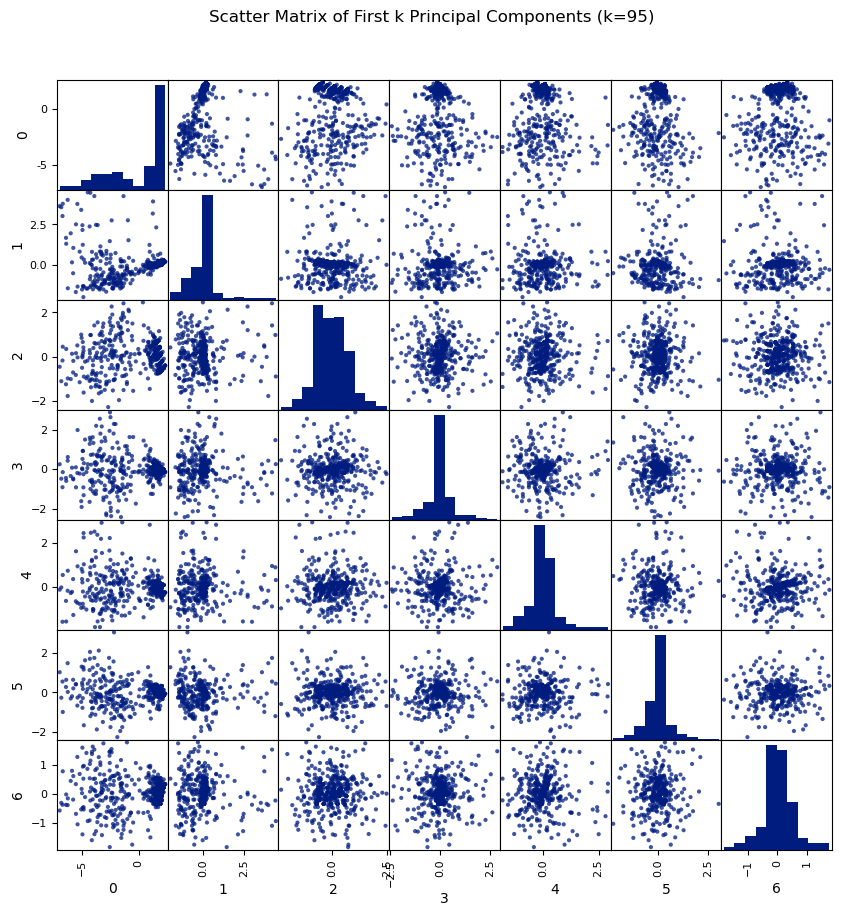

In [209]:
axes = pd.plotting.scatter_matrix(
    X_train_hat,  # Dataframe of the projected data
    alpha=0.75,  # Transparency of points
    figsize=(10, 10),  # Size of the figure
)
plt.suptitle('Scatter Matrix of First k Principal Components (k=95)', y=.95)  # Adding a title
plt.show()

Now, we can create a $k$-NN classifer for the projected data, training, predicting, and evaluating.

k=1 accuracy: 0.9645

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.97       114
   Malignant       0.96      0.93      0.94        55

    accuracy                           0.96       169
   macro avg       0.96      0.95      0.96       169
weighted avg       0.96      0.96      0.96       169



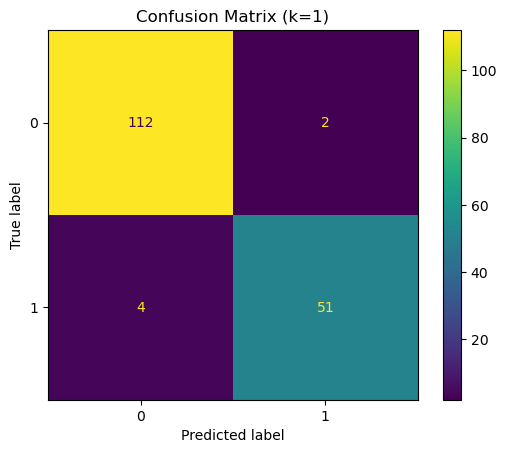

In [210]:
# Making the k-NN model with k=1
knn_k95 = KNeighborsClassifier(n_neighbors=1)
knn_k95.fit(X_train_hat, y_train)  # Fit the model with the new projected data

# Get the predictions and accuracy of the new projected data
y_pred_k95 = knn_k95.predict(X_test_hat)
acc_k95 = accuracy_score(y_test, y_pred_k95)

# Evaluating the model
print(f"k=1 accuracy: {acc_k95:.4f}")  # Print accuracy to 4 decimal places
print("\nClassification Report:")
print(classification_report(y_test, y_pred_k95, target_names=['Benign', 'Malignant']))

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_k95, display_labels=knn_k95.classes_)
plt.title("Confusion Matrix (k=1)")
plt.show()

## Problem 10 - Dimension Reduction II

To determine the number of principle components to acheive **80%** accuracy, we can mirror the previous steps. Additionally, we can define functions for a level of abstraction:

In [211]:
def reduce_get_k_acc(VARIANCE: float = .80, cumulative_energy: np.array = [], k_arg: int = None,):
    ''' 
    Returns the minimum number of principal components to achieve the desired variance and the accuracy of k-NN with k=1 
    Parameters:
        - VARIANCE: The desired variance to achieve (between 0 and 1)
        - cumulative_energy: The cumulative energy array from PCA
    Returns:
        - k: The minimum number of principal components to achieve the desired variance
        - knn_k: The k-NN model trained on the projected data
        - acc_k: The accuracy of the k-NN model on the test set
    '''
    
    # Getting smallest k value where cumulative energy >= DESIRED_VARIANCE
    if k_arg is None:
        k = int(np.argmax(cumulative_energy >= VARIANCE) + 1)
    else:
        k = k_arg
        
    V_hat = eigenvectors[:, :k].copy()  # Projection matrix using the first k eigenvectors

    X_train_hat = X_train @ V_hat  # Projecting X_train onto R^k
    X_test_hat = X_test @ V_hat  # Projecting X_test onto R^k
    
    # Making the k-NN model with k=1
    knn_k = KNeighborsClassifier(n_neighbors=1)
    knn_k.fit(X_train_hat, y_train)  # Fit the model with the new projected data

    # Get the predictions and accuracy of the new projected data
    y_pred_k = knn_k.predict(X_test_hat)
    acc_k = accuracy_score(y_test, y_pred_k)
    
    return k, knn_k, acc_k, X_train_hat, X_test_hat, y_pred_k

def plot_with_scatter_matrix(k_hat: np.array, title: str = "Scatter Matrix of Principal Components") -> None:
    ''' Plots a scatter matrix of the given projected data '''
    axes = pd.plotting.scatter_matrix(
        k_hat,  # Numpy array of the projected data
        alpha=0.75,  # Transparency of points
        figsize=(10, 10),  # Size of the figure
    )
    plt.suptitle(title, y=.95)  # Adding a title
    plt.show()

def eval_knn_model(knn_model: KNeighborsClassifier, y_test: pd.DataFrame, y_pred: np.array) -> None:
    ''' Evaluates the given k-NN model and prints the accuracy, classification report, and confusion matrix '''
    # Get the accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Evaluating the model
    print(f"k=1 accuracy: {acc:.4f}")  # Print accuracy to 4 decimal places
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

    # Display the confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=knn_model.classes_)
    plt.title("Confusion Matrix (k=1)")
    plt.show()

Now, we can use these defined functions to analyze dimension reduction for a variance of .85.

Number of principal components to achieve 80% variance: 3
k-NN accuracy using 3 components: 0.9586


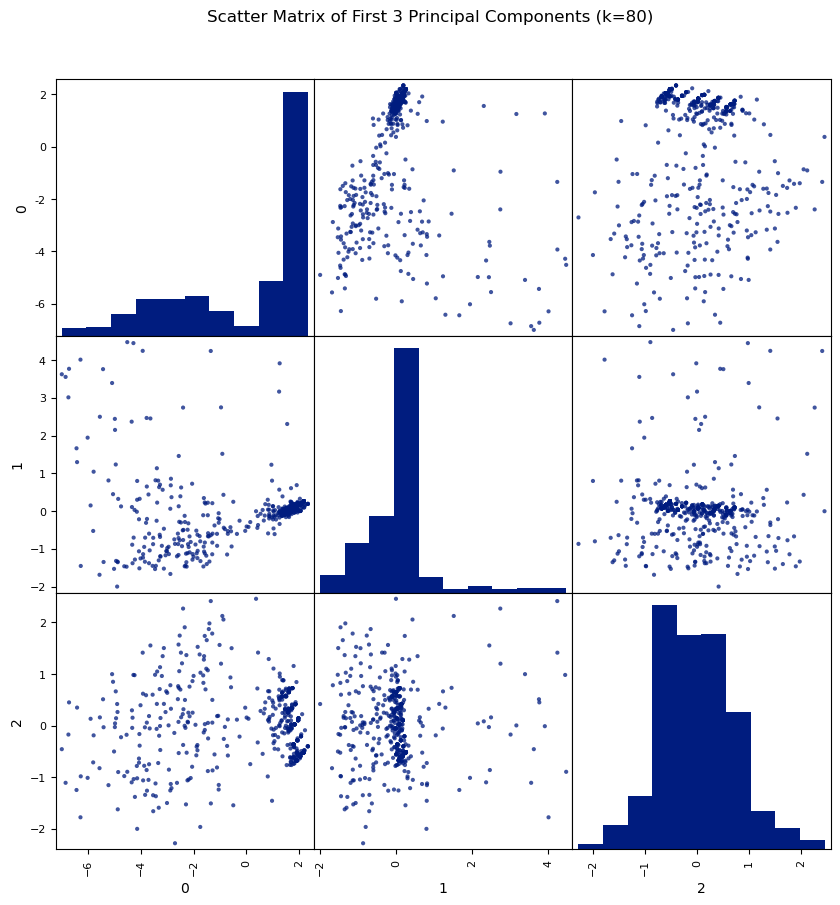

k=1 accuracy: 0.9586

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97       114
   Malignant       0.94      0.93      0.94        55

    accuracy                           0.96       169
   macro avg       0.95      0.95      0.95       169
weighted avg       0.96      0.96      0.96       169



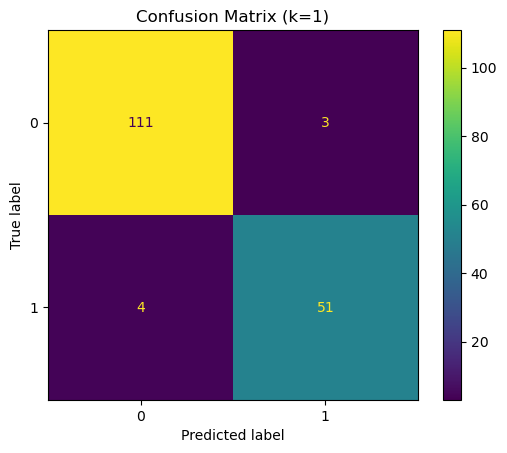

In [212]:
# Get the PCA results for 80% variance
num_components_k80, knn_model_k80, accuracy_k80, X_train_hat_k80, X_test_hat_k80, y_pred_k80 = reduce_get_k_acc(0.80, cumulative_energy)
# Validate results
print(f"Number of principal components to achieve 80% variance: {num_components_k80}")
print(f"k-NN accuracy using {num_components_k80} components: {accuracy_k80:.4f}")

# Printing the scatter matrix for k=80% variance
plot_with_scatter_matrix(X_train_hat_k80, title=f"Scatter Matrix of First {num_components_k80} Principal Components (k=80)")

# Evaluating the k-NN model for k=80% variance
eval_knn_model(knn_model_k80, y_test, y_pred_k80)

## Problem 11 - Further Analysis

When considering the trends from the previous observations, I hypothesize that the **minimum** number of principle components needed to obtain a reasoanble accuracy would be at most **3** principle components, potentially less. To test this hypothesis, we can use some of the previous functions to test the dimensionality and nearest neighbor parameters to determine the optimal amount for this dataset.

In [213]:
k_possibilities = range(1, len(feature_cols))  # Possible k values from 1 to number of features
k_accuracies = {}  # Dict to store accuracies for each (k, n) combination
MAX_N = 50  # Reasonable upper bound as seen previously

# Testing all combinations of k values and k-NN neighbors
for k in k_possibilities:
    _, _, accuracy_k, X_train_hat, X_test_hat, y_pred_k = reduce_get_k_acc(cumulative_energy=cumulative_energy, k_arg=int(k))  # Get the projected data for current k
    # Given the new feature space, test k-NN with different k values (nearest neighbors, in this case)
    for n in range(1, 50):
        knn_model = KNeighborsClassifier(n_neighbors=n)
        knn_model.fit(X_train_hat, y_train)
        y_pred = knn_model.predict(X_test_hat)
        acc = accuracy_score(y_test, y_pred)
        k_accuracies[(k, n)] = acc  # Store accuracy with (num_components, k) as key
        
# Finding the best (k, n) combination
best_k, best_n = max(k_accuracies, key=k_accuracies.get)
print(f"Best number of principal components: {best_k} with k-NN neighbors: {best_n} achieving accuracy: {k_accuracies[(best_k, best_n)]:.4f}")

Best number of principal components: 1 with k-NN neighbors: 5 achieving accuracy: 0.9822


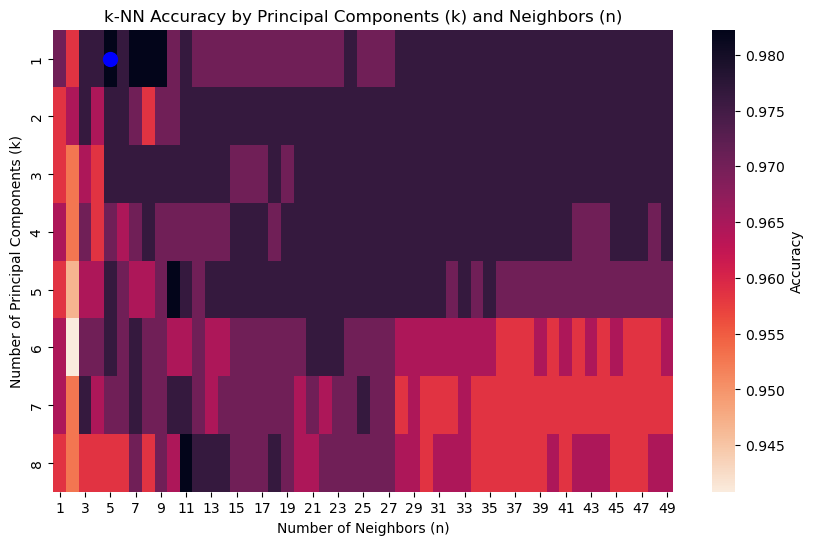

In [214]:
''' Visualizing the accuracies with a heatmap '''
# Convert k_accuracies dict to a DataFrame for visualization
k_acc_df = pd.DataFrame(
    [(k, n, acc) for (k, n), acc in k_accuracies.items()],  # Depacks the dictionary into a list
    columns=['num_components', 'num_neighbors', 'accuracy']
)

# Pulling out the data for the heatmap
heatmap_data = k_acc_df.pivot(index='num_components', columns='num_neighbors', values='accuracy')
plt.figure(figsize=(10, 6))
# Adding the data, giving it a heatmap color (reversed), and assigning a label to the colorbar
ax = sns.heatmap(heatmap_data, annot=False, cmap="rocket_r", cbar_kws={'label': 'Accuracy'})
# Highlighting the best (k, n) point
ax.scatter([list(heatmap_data.columns).index(best_n) + .5],  # Add .5 offset for formatting 
           [list(heatmap_data.index).index(best_k) + .5], color='blue', s=100, label='Best (k, n)')
# Adding formatting details
plt.title('k-NN Accuracy by Principal Components (k) and Neighbors (n)')
plt.xlabel('Number of Neighbors (n)')
plt.ylabel('Number of Principal Components (k)')
plt.show()

#### Analysis Conclusion

As we can see, the optimal (and minimum) **number of principle components** is actually **1**, with the optimal **nearest neighbors** as **5**. This is reinforced in the heatmap, with similar high-accuracy results using only 1 principle component.
This result points to noise in the dataset, showing that **1 feature** is significantly more impactful when predicting the breast cancer type, having a culmulative energy of around *$66\%$*  but obtaining a very reasonable accuracy of approximately *$98\%$*. 

## Problem 12 - AI Usage Report - N/A